Problem 2: Random Forest Ensemble

In [2]:
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, log_loss

In [3]:
# import fetch dataset 
spambase = fetch_ucirepo(id=94) 
  
# data (as pandas dataframes) 
X = spambase.data.features 
y = spambase.data.targets 
  
# metadata 
#print(spambase.metadata) 
  
# variable information 
#print(spambase.variables) 


1. Use an existing package to train a Random Forest ensemble with 10, 50, 100, and 500 decision trees on the SPAMBASE dataset. Report
accuracy, F1 score, and AUC on both the training and testing sets for $T \in \{10, 50, 100, 500\}$. How do the metrics change as $T$
increases?

In [4]:
# split data into training and test sets:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

trees = [10, 50, 100, 500]
rows = []

for t in trees:
    rf = RandomForestClassifier(n_estimators=t)
    rf.fit(X_train, y_train)

    for train_or_test, x, y_true in [("Train", X_train, y_train),
                                  ("Test",  X_test,  y_test)]:
        
        y_pred = rf.predict(x)

        rows.append({
            "Train or Test": train_or_test,
            "Trees": t,
            "Train or Test": train_or_test,
            "Accuracy": accuracy_score(y_true, y_pred),
            "F1": f1_score(y_true, y_pred),
            "AUC": roc_auc_score(y_true, y_pred)
        })
    
pd.DataFrame(rows).set_index("Train or Test")

/Users/pavithra/anaconda3/lib/python3.11/site-packages/sklearn/base.py:1151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/pavithra/anaconda3/lib/python3.11/site-packages/sklearn/base.py:1151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/pavithra/anaconda3/lib/python3.11/site-packages/sklearn/base.py:1151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/pavithra/anaconda3/lib/python3.11/site-packages/sklearn/base.py:1151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. P

,Trees,Accuracy,F1,AUC
Train or Test,,,,
Train,10,0.997283,0.996484,0.997006
Test,10,0.943540,0.930851,0.937419
Train,50,0.999185,0.998946,0.999076
Test,50,0.955483,0.945695,0.950159
Train,100,0.999457,0.999297,0.999297
Test,100,0.958740,0.950262,0.955027
Train,500,0.999457,0.999297,0.999427
Test,500,0.958740,0.949868,0.954006


As T increases, the metrics for the train dataset also seem to slightly increase for each metric. It also seems that at T=100 and T=500, some of the metrics, such as accuracy, and F1 score are the same for both T values. 
For the test dataset, as T increases, we see the same pattern where the metrics show an overall increasing trend. However, it seems that for T=100 to T=500, the metrics actually decrease slighlty just for the test dataset.

2. Compare the metrics obtained for Random Forest with the Decision tree metrics obtained in Problem 1. Write down some observations.

The train dataset from problem 1 accuracy, F1 and AUC metrics are most similar to the train dataset on Random Forest in this problem where T=500 where accuracy = 0.999457, F1 = 0.999297, and AUC = 0.999297 for both. The test dataset from problem 1 has similar metrics to the test set in this problem where T=10, although the metrics are not exactly the same. 

3. Compute the variable importance for each feature and include a plot.

Feature: word_freq_make, Score: 0.00423
Feature: word_freq_address, Score: 0.00571
Feature: word_freq_all, Score: 0.01107
Feature: word_freq_3d, Score: 0.00106
Feature: word_freq_our, Score: 0.03505
Feature: word_freq_over, Score: 0.00753
Feature: word_freq_remove, Score: 0.08058
Feature: word_freq_internet, Score: 0.01088
Feature: word_freq_order, Score: 0.00394
Feature: word_freq_mail, Score: 0.00844
Feature: word_freq_receive, Score: 0.00863
Feature: word_freq_will, Score: 0.01185
Feature: word_freq_people, Score: 0.00374
Feature: word_freq_report, Score: 0.00217
Feature: word_freq_addresses, Score: 0.00177
Feature: word_freq_free, Score: 0.07274
Feature: word_freq_business, Score: 0.01398
Feature: word_freq_email, Score: 0.00861
Feature: word_freq_you, Score: 0.02832
Feature: word_freq_credit, Score: 0.00534
Feature: word_freq_your, Score: 0.04864
Feature: word_freq_font, Score: 0.00227
Feature: word_freq_000, Score: 0.02485
Feature: word_freq_money, Score: 0.03295
Feature: word_fr

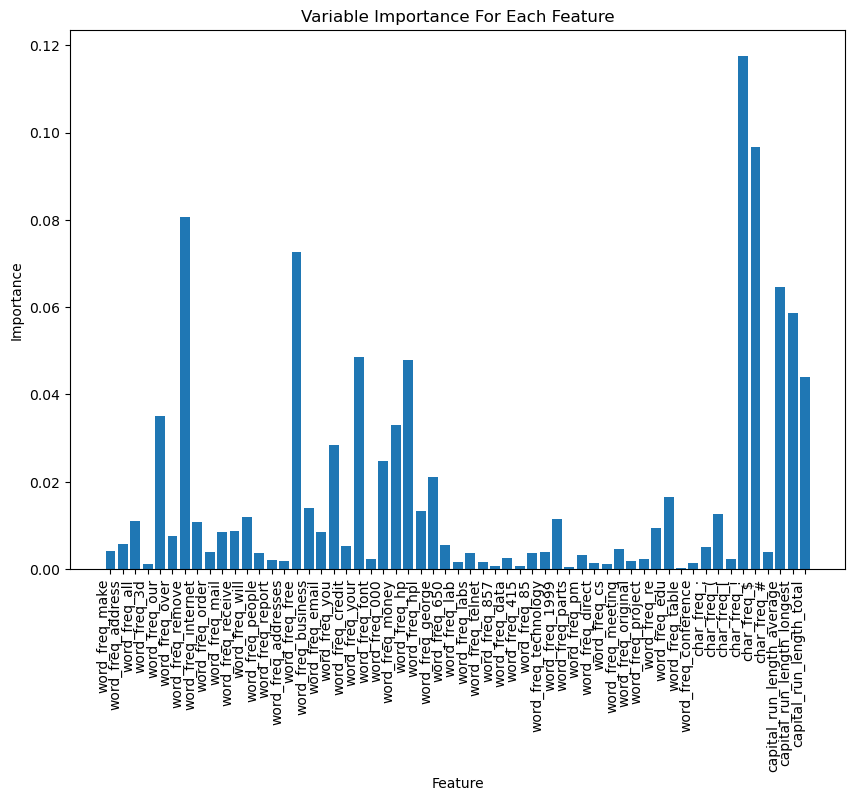

In [15]:
importances = rf.feature_importances_
features_names = X_train.columns

# summarize feature importance
for feature, score in zip(features_names, importances):
	print('Feature: %s, Score: %.5f' % (feature, score))

# plot feature importance
plt.figure(figsize=(10,7))
plt.bar(features_names, importances)
plt.xticks(features_names, rotation=90, ha='right') # ha='right' adjusts alignment for better fit
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Variable Importance For Each Feature")
plt.show()